# <font>Retail Sales Analytics</font>

### Import necessary Libraries

In [2]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
 
from sklearn.impute import SimpleImputer 
from sklearn.preprocessing import LabelEncoder 
 
import scipy.stats as stats 
 
import warnings 
warnings.filterwarnings('ignore') 

In [3]:
features = pd.read_csv("features.csv.xls")
features.head()

,Store,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday
0,1,2010-02-05,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False
1,1,2010-02-12,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,True
2,1,2010-02-19,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,False
3,1,2010-02-26,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,False
4,1,2010-03-05,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,False


In [4]:
features.shape

(8190, 12)

**In Features has 8190 rows and 12 columns**

In [5]:
stores = pd.read_csv("stores.csv.xls")
stores.head()

,Store,Type,Size
0,1,A,151315
1,2,A,202307
2,3,B,37392
3,4,A,205863
4,5,B,34875


In [6]:
stores.shape

(45, 3)

In [7]:
train = pd.read_csv("train.csv.xls")
train.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,2010-02-05,24924.50,False
1,1,1,2010-02-12,46039.49,True
2,1,1,2010-02-19,41595.55,False
3,1,1,2010-02-26,19403.54,False
4,1,1,2010-03-05,21827.90,False


In [8]:
train.shape

(421570, 5)

In [9]:
# Convert the Date column to datetime format for accurate merging
features["Date"] = pd.to_datetime(features["Date"])
train["Date"] = pd.to_datetime(train["Date"])

In [10]:
# Merge train with features on 'Store' and 'Date'
df = pd.merge(train, features, how="inner")
df

,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment
0,1,1,2010-02-05,24924.50,False,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106
1,1,1,2010-02-12,46039.49,True,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106
2,1,1,2010-02-19,41595.55,False,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106
3,1,1,2010-02-26,19403.54,False,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106
4,1,1,2010-03-05,21827.90,False,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
421565,45,98,2012-09-28,508.37,False,64.88,3.997,4556.61,20.64,1.50,1601.01,3288.25,192.013558,8.684
421566,45,98,2012-10-05,628.10,False,64.89,3.985,5046.74,NaN,18.82,2253.43,2340.01,192.170412,8.667
421567,45,98,2012-10-12,1061.02,False,54.47,4.000,1956.28,NaN,7.89,599.32,3990.54,192.327265,8.667
421568,45,98,2012-10-19,760.01,False,56.47,3.969,2004.02,NaN,3.18,437.73,1537.49,192.330854,8.667


In [11]:
df.shape

(421570, 14)

In [12]:
# Merge the result with stores on 'Store'
df = pd.merge(df, stores, on="Store", how="inner")


In [13]:
df.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size
0,1,1,2010-02-05,24924.50,False,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,A,151315
1,1,1,2010-02-12,46039.49,True,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,A,151315
2,1,1,2010-02-19,41595.55,False,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,A,151315
3,1,1,2010-02-26,19403.54,False,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,A,151315
4,1,1,2010-03-05,21827.90,False,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,A,151315


In [14]:
df.shape

(421570, 16)

**df DataFrame has 421570 and 16 rows in initial phase**

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   Store         421570 non-null  int64         
 1   Dept          421570 non-null  int64         
 2   Date          421570 non-null  datetime64[ns]
 3   Weekly_Sales  421570 non-null  float64       
 4   IsHoliday     421570 non-null  bool          
 5   Temperature   421570 non-null  float64       
 6   Fuel_Price    421570 non-null  float64       
 7   MarkDown1     150681 non-null  float64       
 8   MarkDown2     111248 non-null  float64       
 9   MarkDown3     137091 non-null  float64       
 10  MarkDown4     134967 non-null  float64       
 11  MarkDown5     151432 non-null  float64       
 12  CPI           421570 non-null  float64       
 13  Unemployment  421570 non-null  float64       
 14  Type          421570 non-null  object        
 15  Size          421

**<pre>Bool Datatype: IsHoliday
Object Dataype: Type
Date type: Date 
Nulls: All MarkDown</pre>**

In [16]:
df.describe()

,Store,Dept,Date,Weekly_Sales,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Size
count,421570.000000,421570.000000,421570,421570.000000,421570.000000,421570.000000,150681.000000,111248.000000,137091.000000,134967.000000,151432.000000,421570.000000,421570.000000,421570.000000
mean,22.200546,44.260317,2011-06-18 08:30:31.963375104,15981.258123,60.090059,3.361027,7246.420196,3334.628621,1439.421384,3383.168256,4628.975079,171.201947,7.960289,136727.915739
min,1.000000,1.000000,2010-02-05 00:00:00,-4988.940000,-2.060000,2.472000,0.270000,-265.760000,-29.100000,0.220000,135.160000,126.064000,3.879000,34875.000000
25%,11.000000,18.000000,2010-10-08 00:00:00,2079.650000,46.680000,2.933000,2240.270000,41.600000,5.080000,504.220000,1878.440000,132.022667,6.891000,93638.000000
50%,22.000000,37.000000,2011-06-17 00:00:00,7612.030000,62.090000,3.452000,5347.450000,192.000000,24.600000,1481.310000,3359.450000,182.318780,7.866000,140167.000000
75%,33.000000,74.000000,2012-02-24 00:00:00,20205.852500,74.280000,3.738000,9210.900000,1926.940000,103.990000,3595.040000,5563.800000,212.416993,8.572000,202505.000000
max,45.000000,99.000000,2012-10-26 00:00:00,693099.360000,100.140000,4.468000,88646.760000,104519.540000,141630.610000,67474.850000,108519.280000,227.232807,14.313000,219622.000000
std,12.785297,30.492054,NaN,22711.183519,18.447931,0.458515,8291.221345,9475.357325,9623.078290,6292.384031,5962.887455,39.159276,1.863296,60980.583328


In [17]:
df.describe(include = ['O'])

,Type
count,421570
unique,3
top,A
freq,215478


In [18]:
(215478 / 421570)*100

51.11321963137795

**Around *51%* Stores are type *A***

In [19]:
df.isnull().sum()

Store                0
Dept                 0
Date                 0
Weekly_Sales         0
IsHoliday            0
Temperature          0
Fuel_Price           0
MarkDown1       270889
MarkDown2       310322
MarkDown3       284479
MarkDown4       286603
MarkDown5       270138
CPI                  0
Unemployment         0
Type                 0
Size                 0
dtype: int64

In [20]:
df[['MarkDown1', 'MarkDown2','MarkDown3','MarkDown4','MarkDown5']].isnull().sum().mean()

np.float64(284486.2)

**Around 284486 Weeks are not any MarkDown scheme is apply**

In [21]:
df[['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5']] = df[['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5']].fillna(0)


In [22]:
df.isnull().sum()

Store           0
Dept            0
Date            0
Weekly_Sales    0
IsHoliday       0
Temperature     0
Fuel_Price      0
MarkDown1       0
MarkDown2       0
MarkDown3       0
MarkDown4       0
MarkDown5       0
CPI             0
Unemployment    0
Type            0
Size            0
dtype: int64

**fill the nulls with 0**

In [23]:
num_columns_means = df.select_dtypes(include=np.number).mean()
num_columns_means

Store               22.200546
Dept                44.260317
Weekly_Sales     15981.258123
Temperature         60.090059
Fuel_Price           3.361027
MarkDown1         2590.074819
MarkDown2          879.974298
MarkDown3          468.087665
MarkDown4         1083.132268
MarkDown5         1662.772385
CPI                171.201947
Unemployment         7.960289
Size            136727.915739
dtype: float64

In [24]:
num_columns_median = df.select_dtypes(include=np.number).median()
num_columns_median

Store               22.00000
Dept                37.00000
Weekly_Sales      7612.03000
Temperature         62.09000
Fuel_Price           3.45200
MarkDown1            0.00000
MarkDown2            0.00000
MarkDown3            0.00000
MarkDown4            0.00000
MarkDown5            0.00000
CPI                182.31878
Unemployment         7.86600
Size            140167.00000
dtype: float64

In [25]:
mode_values = df.mode().iloc[0]
mode_values

Store                          13.0
Dept                              1
Date            2011-12-23 00:00:00
Weekly_Sales                   10.0
IsHoliday                     False
Temperature                   50.43
Fuel_Price                    3.638
MarkDown1                       0.0
MarkDown2                       0.0
MarkDown3                       0.0
MarkDown4                       0.0
MarkDown5                       0.0
CPI                      129.855533
Unemployment                  8.099
Type                              A
Size                        39690.0
Name: 0, dtype: object

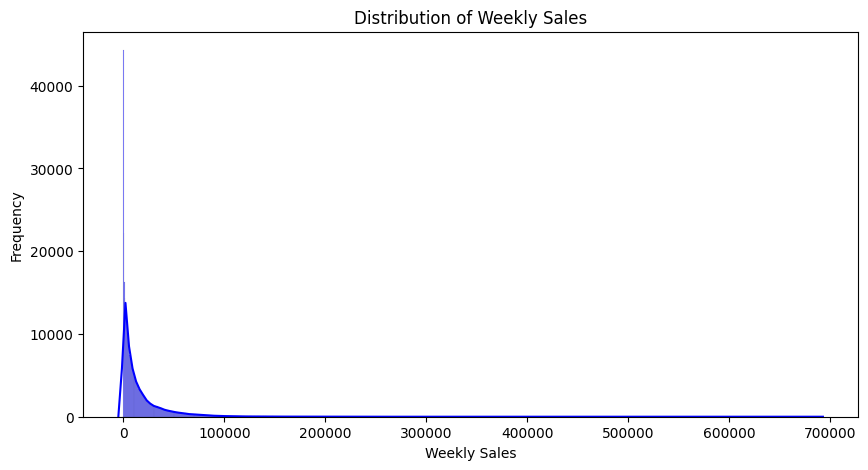

In [26]:
# Plot histogram & KDE for Weekly Sales
plt.figure(figsize=(10, 5))
sns.histplot(df['Weekly_Sales'], kde=True, color='blue')
plt.title('Distribution of Weekly Sales')
plt.xlabel('Weekly Sales')
plt.ylabel('Frequency')
plt.show()


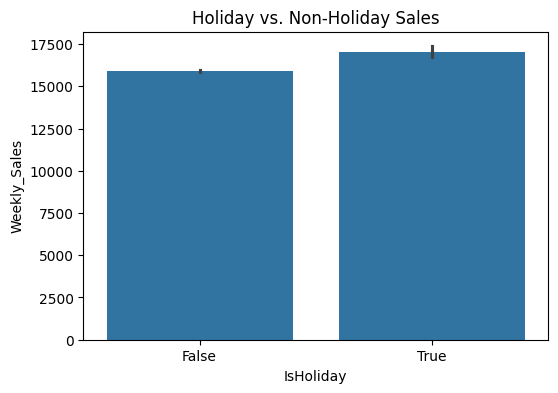

In [27]:
plt.figure(figsize=(6, 4))
sns.barplot(x="IsHoliday", y="Weekly_Sales", data=df)
plt.title("Holiday vs. Non-Holiday Sales")
plt.show()


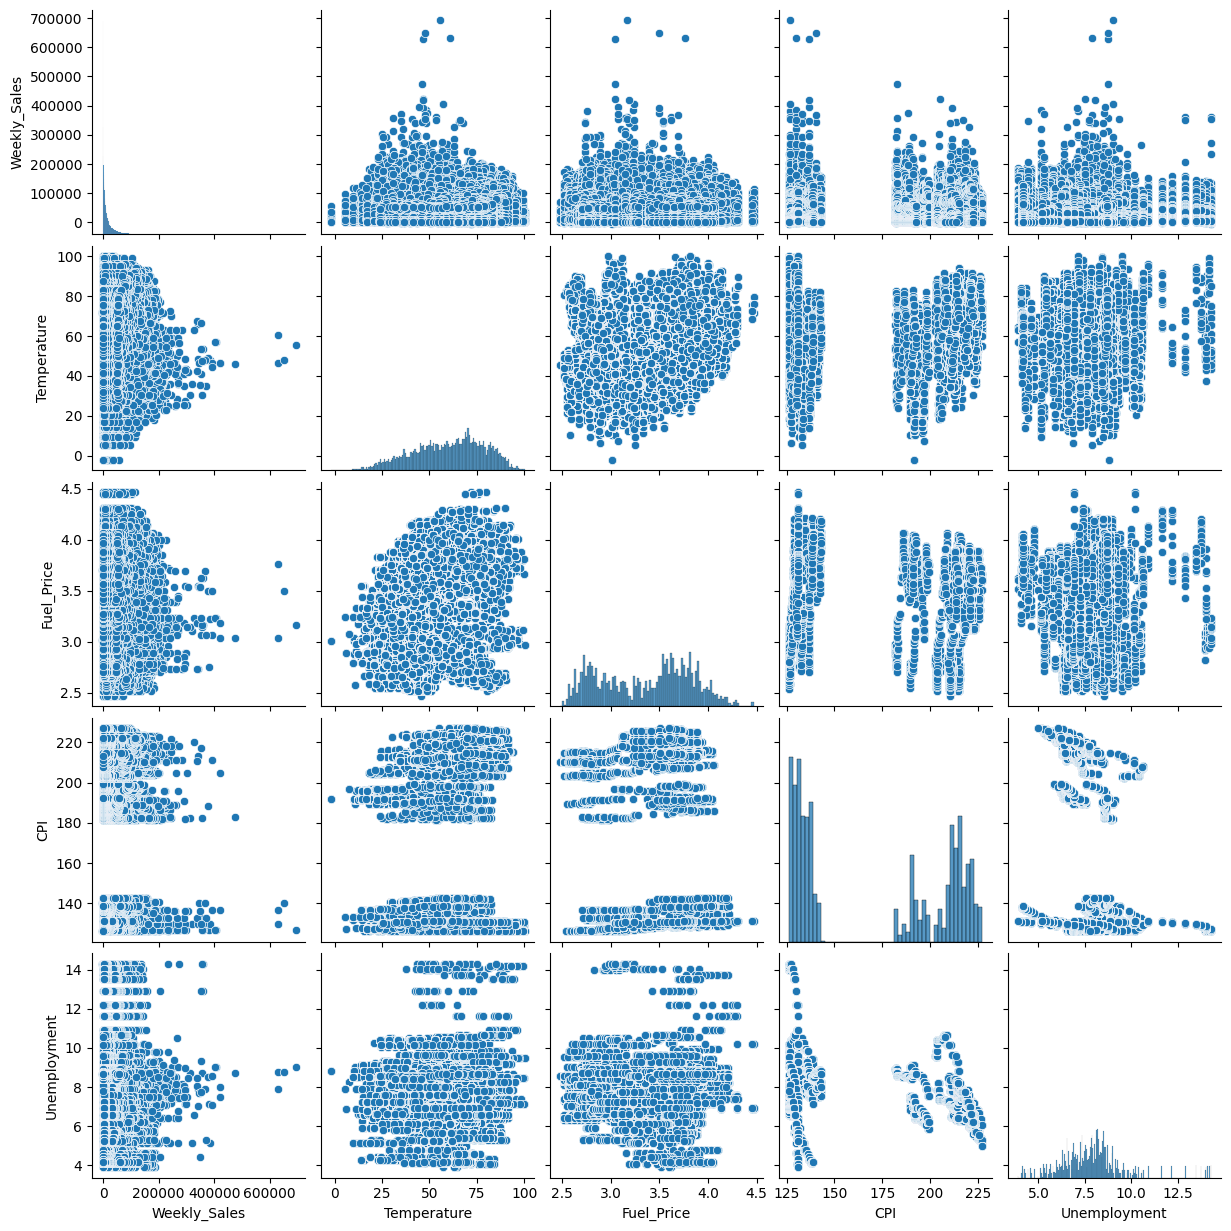

In [28]:
sns.pairplot(df[['Weekly_Sales', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment']])
plt.show()


In [34]:
df.drop(['Date','Type'], axis=1).skew()

Store            0.077763
Dept             0.358223
Weekly_Sales     3.262008
IsHoliday        3.359867
Temperature     -0.321404
Fuel_Price      -0.104901
MarkDown1        4.731304
MarkDown2       10.645956
MarkDown3       14.922341
MarkDown4        8.077666
MarkDown5        9.964519
CPI              0.085219
Unemployment     1.183743
Size            -0.325850
dtype: float64

In [35]:
df.drop(['Date','Type'], axis=1).kurt()

Store            -1.146503
Dept             -1.215571
Weekly_Sales     21.491290
IsHoliday         9.288747
Temperature      -0.635922
Fuel_Price       -1.185405
MarkDown1        34.917236
MarkDown2       145.421293
MarkDown3       248.095371
MarkDown4        86.242339
MarkDown5       183.408065
CPI              -1.829714
Unemployment      2.731217
Size             -1.206346
dtype: float64

<Axes: >

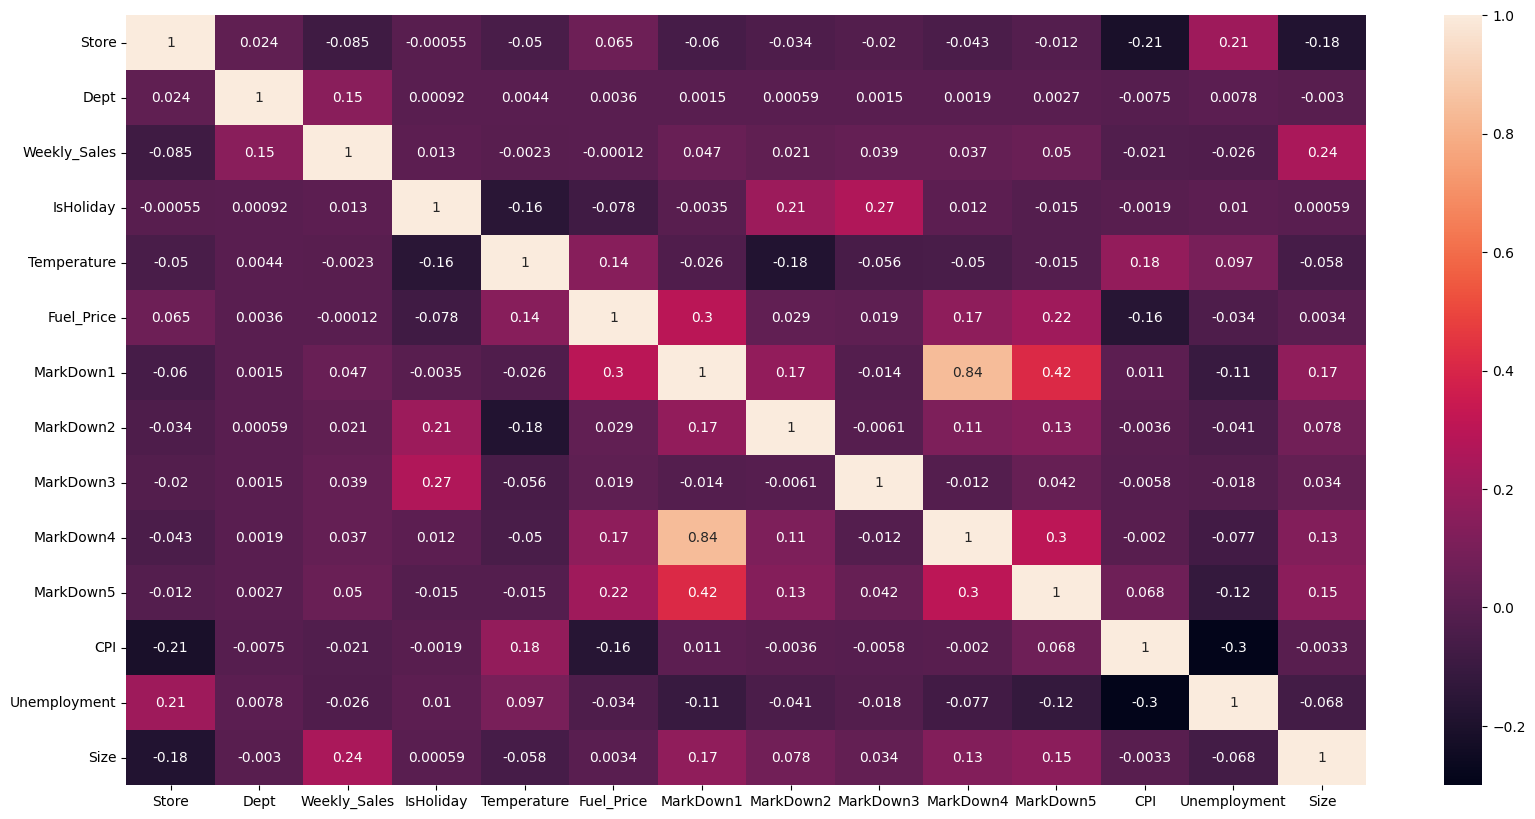

In [40]:
plt.figure(figsize=[20,10])
sns.heatmap(df.drop(['Date','Type'], axis=1).corr(), annot = True)

In [ ]:
sns.heatmap(df[['Weekly_Sales', 'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5']].corr(), annot = True)

In [ ]:
sns.lineplot(x=df["MarkDown1"], y=df["MarkDown5"])

In [ ]:

# Plotting the lines
plt.plot(df["MarkDown1"], label='Line 1')
plt.plot(df["MarkDown5"], label='Line 5')
plt.plot(df["MarkDown3"], label='Line 5')

# Adding labels and title
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.title('Two Lines on One Plot')

# Adding a legend
plt.legend()

# Displaying the plot
plt.show()

In [ ]:
sns.lineplot(x=df["MarkDown1"],y=df["Weekly_Sales"], label='Line 1')
sns.lineplot(x=df["MarkDown5"],y=df["Weekly_Sales"], label='Line 2')

# Displaying the plot
plt.show()

In [ ]:
sns.lineplot(x=df["MarkDown1"],y=df["MarkDown5"], label='Line 1')


# Displaying the plot
plt.show()

In [ ]:
sns.scatterplot(x=df["MarkDown1"], y=df["Weekly_Sales"])
plt.title("Weekly Sales vs. MarkDown1")
plt.show()

In [ ]:
df.groupby('Type')[['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5']].mean()
